        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
          RI     Na   Mg    Al     Si     K    Ca    Ba   Fe  Type
209  1.51623  14.14  0.0  2.88  72.61  0.08  9.18  1.06  0.0     7
210  1.51685  14.92  0.0  1.99  73.06  0.00  8.40  1.59  0.0     7
211  1.52065  14.36  0.0  2.02  73.42  0.00  8.44  1.64  0.0     7
212  1.51651  14.38  0.0  1.94  73.61  0.00  8.48  1.57  0.0     7
213  1.51711  14.23  0.0  2.08  73.36  0.00  8.62  1.67  0.0     7
(214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 no

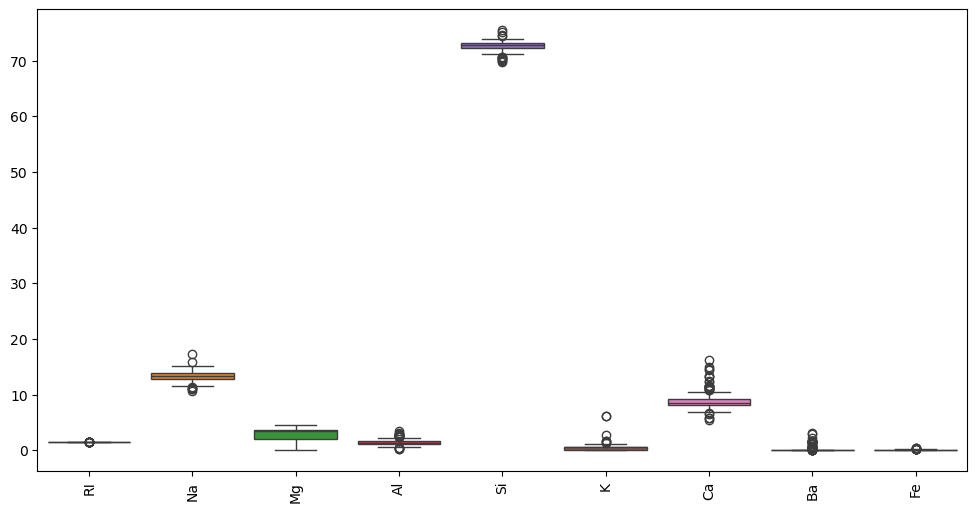


Class Distribution:
 Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [1]:
#1. Exploratory Data Analysis (EDA):
'''
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.
'''
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\glass.xlsx")

# BASIC STRUCTURE
print(df.head())
print(df.tail())
print(df.shape)
print(df.info())
print(df.describe())

# MISSING VALUES
print("\nMissing Values:\n", df.isnull().sum())

# DUPLICATE RECORDS
print("\nDuplicate Rows:", df.duplicated().sum())

# DATA TYPE CONSISTENCY
print("\nData Types:\n", df.dtypes)

# OUTLIER DETECTION (IQR METHOD)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
print("\nOutliers Count Per Feature:\n", outliers.sum())

#VISUAL OUTLIER CHECK
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['Type'], errors='ignore'))
plt.xticks(rotation=90)
plt.show()

#CLASS DISTRIBUTION
if 'Type' in df.columns:
    print("\nClass Distribution:\n", df['Type'].value_counts())


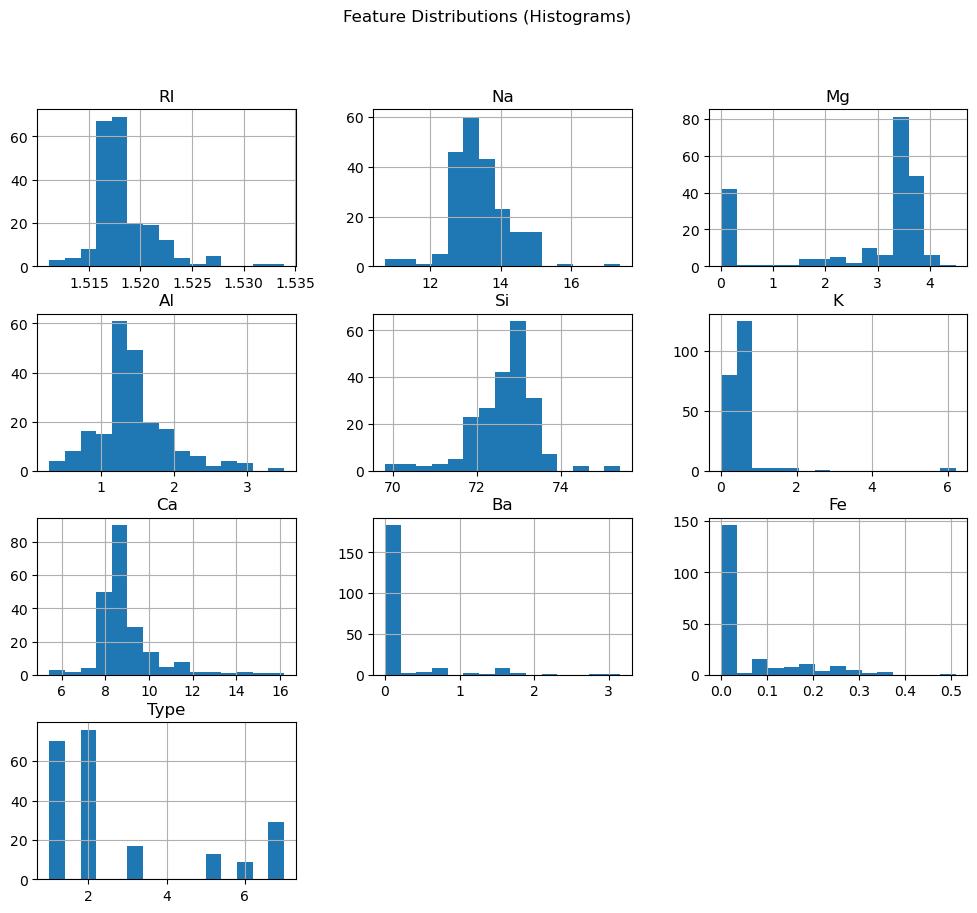

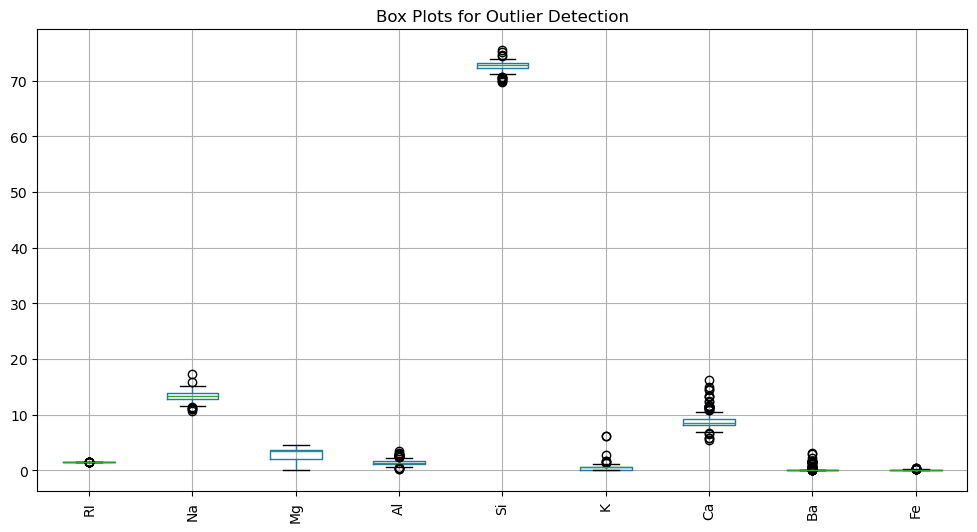

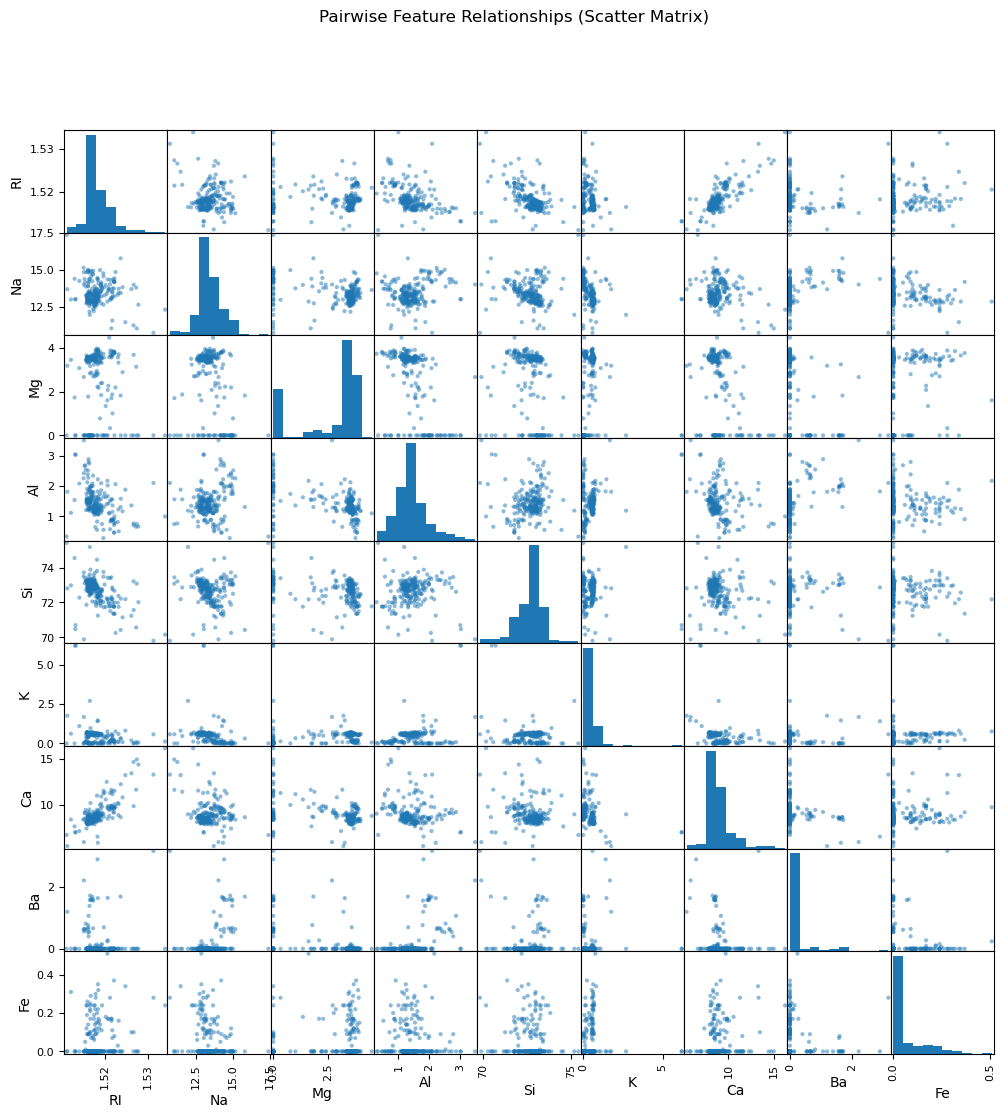

Correlation Matrix:
             RI        Na        Mg        Al        Si         K        Ca  \
RI    1.000000 -0.191885 -0.122274 -0.407326 -0.542052 -0.289833  0.810403   
Na   -0.191885  1.000000 -0.273732  0.156794 -0.069809 -0.266087 -0.275442   
Mg   -0.122274 -0.273732  1.000000 -0.481799 -0.165927  0.005396 -0.443750   
Al   -0.407326  0.156794 -0.481799  1.000000 -0.005524  0.325958 -0.259592   
Si   -0.542052 -0.069809 -0.165927 -0.005524  1.000000 -0.193331 -0.208732   
K    -0.289833 -0.266087  0.005396  0.325958 -0.193331  1.000000 -0.317836   
Ca    0.810403 -0.275442 -0.443750 -0.259592 -0.208732 -0.317836  1.000000   
Ba   -0.000386  0.326603 -0.492262  0.479404 -0.102151 -0.042618 -0.112841   
Fe    0.143010 -0.241346  0.083060 -0.074402 -0.094201 -0.007719  0.124968   
Type -0.164237  0.502898 -0.744993  0.598829  0.151565 -0.010054  0.000952   

            Ba        Fe      Type  
RI   -0.000386  0.143010 -0.164237  
Na    0.326603 -0.241346  0.502898  
Mg   -0.4

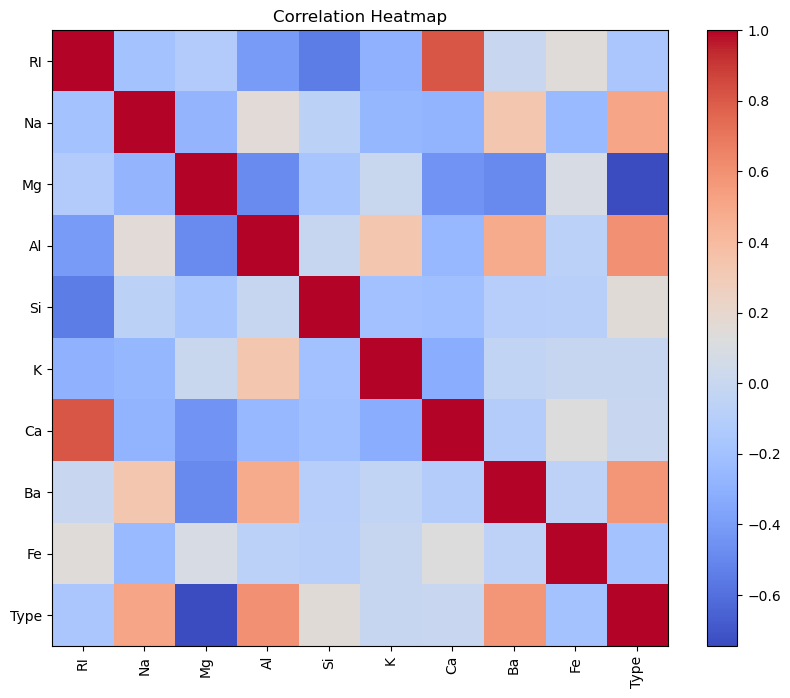

In [2]:
#2: Data Visualization:
'''
Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.
'''
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Load dataset
df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\glass.xlsx")   # or pd.read_csv("glass.csv")

# -------------------- HISTOGRAMS --------------------
df.hist(figsize=(12, 10), bins=15)
plt.suptitle("Feature Distributions (Histograms)")
plt.show()

# -------------------- BOX PLOTS --------------------
plt.figure(figsize=(12, 6))
df.drop(columns=['Type'], errors='ignore').boxplot()
plt.xticks(rotation=90)
plt.title("Box Plots for Outlier Detection")
plt.show()

# -------------------- PAIR PLOTS (SCATTER MATRIX) --------------------
scatter_matrix(
    df.drop(columns=['Type'], errors='ignore'),
    figsize=(12, 12),
    diagonal='hist'
)
plt.suptitle("Pairwise Feature Relationships (Scatter Matrix)")
plt.show()

# -------------------- CORRELATION MATRIX --------------------
corr = df.corr()
print("Correlation Matrix:\n", corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


In [4]:
#3: Data Preprocessing
'''
1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.
'''
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# -------------------- LOAD DATASET --------------------
df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\glass.xlsx")   # change to glass.csv if needed

# -------------------- 1. MISSING VALUES HANDLING --------------------
print("Missing Values Before Handling:\n", df.isnull().sum())

# Mean imputation for numerical columns (safe & future-proof)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

print("\nMissing Values After Handling:\n", df.isnull().sum())

# -------------------- 2. ENCODING CATEGORICAL VARIABLES --------------------
cat_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:", cat_cols)

# One-hot encoding (if categorical columns exist)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# -------------------- 3. FEATURE SCALING --------------------
X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------- 4. HANDLING IMBALANCED DATA --------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# -------------------- FINAL OUTPUT --------------------
print("\nOriginal Dataset Shape:", X.shape, y.shape)
print("After SMOTE Shape:", X_resampled.shape, y_resampled.shape)
print("\nPreprocessing Completed Successfully")


Missing Values Before Handling:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Missing Values After Handling:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Categorical Columns: Index([], dtype='object')

Original Dataset Shape: (214, 9) (214,)
After SMOTE Shape: (456, 9) (456,)

Preprocessing Completed Successfully


In [5]:
#4: Random Forest Model Implementation
'''
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.
'''
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------- 1. TRAIN–TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# -------------------- 2. RANDOM FOREST MODEL --------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# -------------------- 3. TRAIN THE MODEL --------------------
rf_model.fit(X_train, y_train)

# -------------------- 4. PREDICTION --------------------
y_pred = rf_model.predict(X_test)

# -------------------- 5. MODEL EVALUATION --------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))




Accuracy: 0.9130434782608695

Classification Report:

              precision    recall  f1-score   support

           1       0.76      0.87      0.81        15
           2       0.93      0.87      0.90        15
           3       0.93      0.87      0.90        15
           5       0.94      0.94      0.94        16
           6       1.00      1.00      1.00        16
           7       0.93      0.93      0.93        15

    accuracy                           0.91        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92

Confusion Matrix:

[[13  1  1  0  0  0]
 [ 2 13  0  0  0  0]
 [ 2  0 13  0  0  0]
 [ 0  0  0 15  0  1]
 [ 0  0  0  0 16  0]
 [ 0  0  0  1  0 14]]


In [7]:
#5: Bagging and Boosting Methods
'''
Apply the Bagging and Boosting methods and compare the results.
'''

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------- BAGGING --------------------
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

print("BAGGING RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag, zero_division=0))


# -------------------- BOOSTING --------------------
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)

print("\nBOOSTING RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost, zero_division=0))



BAGGING RESULTS
Accuracy: 0.8913043478260869
              precision    recall  f1-score   support

           1       0.75      0.80      0.77        15
           2       0.85      0.73      0.79        15
           3       0.93      0.93      0.93        15
           5       0.94      0.94      0.94        16
           6       0.94      1.00      0.97        16
           7       0.93      0.93      0.93        15

    accuracy                           0.89        92
   macro avg       0.89      0.89      0.89        92
weighted avg       0.89      0.89      0.89        92


BOOSTING RESULTS
Accuracy: 0.3804347826086957
              precision    recall  f1-score   support

           1       0.33      0.87      0.47        15
           2       0.00      0.00      0.00        15
           3       0.50      0.07      0.12        15
           5       0.29      0.50      0.36        16
           6       0.00      0.00      0.00        16
           7       0.81      0.87      0

Additional Notes:

1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging (Bootstrap Aggregating) and Boosting are two popular ensemble learning techniques used to improve the performance of machine learning models by 
combining multiple weak learners.

Bagging works by creating several subsets of the original dataset using random sampling with replacement (bootstrap sampling). Each subset is used to 
train a separate model independently. The final prediction is obtained by averaging (for regression) or majority voting (for classification) across all 
models. Bagging mainly helps to reduce variance and prevent overfitting, especially in high-variance models like decision trees.

Boosting, on the other hand, builds models sequentially, where each new model tries to correct the mistakes made by the previous ones. It assigns higher 
weights to misclassified data points, forcing the next model to focus more on difficult cases. The final prediction is a weighted combination of all 
models. Boosting mainly helps to reduce bias and improve accuracy, making it powerful for complex datasets.

The key difference between them is that bagging trains models independently in parallel, focusing on reducing variance, while boosting trains models 
sequentially, focusing on reducing bias by learning from errors of previous models.


2. Explain how to handle imbalance in the data.

Handling imbalance in data is important because most machine learning models assume that all classes are equally represented, and when one class dominate
the model tends to be biased toward it, leading to poor performance on the minority class. To address this, we can use resampling techniques such as 
oversampling, where the minority class is increased by duplicating samples or generating synthetic data using methods like SMOTE, and undersampling,
where the majority class is reduced by removing samples. Another approach is to use algorithm-level solutions such as assigning class weights to 
penalize misclassification of the minority class, or using models like Random Forest and XGBoost that perform better on imbalanced data. It is also 
important to evaluate the model using appropriate metrics like precision, recall, F1-score, and ROC-AUC instead of accuracy, because accuracy can be 
misleading in imbalanced datasets. Additionally, threshold adjustment can help by changing the probability cut-off for class prediction, and ensemble 
methods or data augmentation (for images and text) can further improve model performance by creating a more balanced and robust training set.
